# The code behind it: build a test by simulating the null

*Part 2 · Lesson 13 · the code behind it  ·  data: simulation on a known population (same as Lesson 13)*

*↩ A companion to [Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb).*

**↩ Back:** [Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](13-hypothesis-testing~another-dataset.ipynb)

**In Lesson 13 the p-value appeared as if by magic** — you slid a known population sideways, drew
thousands of samples, and counted the extreme ones. This companion **opens the hood on that machine**:
you'll write the null-world simulation *yourself*, so "p-value," "Type I error," and "power" stop being
words and become a few lines of NumPy you could reproduce from memory.

Same Ames housing population, same idea, same final numbers — but the focus shifts from *what a test
means* to **how you build one in Python**. We'll go in the order a programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — load the population, fix a null claim, take one sample, form the statistic.
3. **Build it step by step** — simulate the null distribution, read a p-value off a boolean mask, check it against `scipy`.
4. **The idiom** — the *vectorized* `(reps, n)` null simulation vs. a slow Python loop.
5. **Refactor into a function** — wrap it all up as your own reusable `sim_p_value()`.
6. **Now you code** — predict-then-run exercises for Type I error and power.
7. **What you learned** — the coding *and* the statistics.

You don't need Lesson 13 fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have written a function that takes an observed statistic and a recipe
for simulating the null, and returns a **p-value** — the same number `scipy.stats.ttest_1samp` hands you
for free. Then you'll reuse that machinery to *measure* two long-run rates with brute force: the **Type I
error rate** (which should sit at $\alpha$) and the **power** (which should rise with effect size and
sample size). Nothing here needs new statistics; everything is the Python *underneath* the test.

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **NumPy** | fast math on whole arrays at once | drawing samples, forming the statistic, the boolean mask |
| **`np.random.default_rng`** | a *seeded* random-number generator | reproducible "chance" — same seed, same numbers every run |
| **scipy.stats** | textbook statistical tests | the `ttest_1samp` we check our simulation against |
| **matplotlib** | plotting | the null-distribution histogram and the power curve |

The one mental model to hold: a **p-value is the fraction of a make-believe "null world" that is at least
as extreme as what we actually saw.** Everything below is a way to *build that null world in code* and
*count*.

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats        # the one-sample t-test we'll check against
sl.use_course_style()

rng = np.random.default_rng(0)   # ONE seeded generator drives every random draw below

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
ames = sl.load_csv('ames.csv', url=AMES_URL)

# Treat the WHOLE file as the population, exactly like the core lesson.
population = ames['area'].dropna().to_numpy()    # above-grade living area, sq ft
MU = population.mean()                            # the TRUE mean — we get to peek at it
N_POP = len(population)
print(f'Loaded a population of {N_POP:,} Ames homes')
print(f'TRUE mean MU = {MU:.1f} sq ft   <- normally hidden; here we can look')

Loaded a population of 2,930 Ames homes
TRUE mean MU = 1499.7 sq ft   <- normally hidden; here we can look


## 2) The data in code: a claim, a sample, a statistic

A hypothesis test needs three concrete things in code. We set up each one, exactly as the core lesson did.

- **A null claim `mu0`.** A realtor insists the typical home has **1,400 sq ft**. That's our null
  hypothesis $H_0:\ \mu = 1400$ — a single, precise number we can simulate.
- **One sample.** We can't see all 2,930 homes; we draw `n = 40` at random with `rng.choice`. We sample
  **with replacement**, treating the file as an effectively infinite super-population — the same modelling
  choice the core lesson makes (it matters later, in Section 6).
- **A test statistic.** We rescale the gap between our sample mean and the claim by the **standard error**
  $s/\sqrt{n}$ to get the **t statistic**, $t = (\bar{x} - \mu_0)/(s/\sqrt{n})$ — "how many standard
  errors is the sample mean from the claim?"

Watch the SD: a *sample* SD divides by $n-1$, so we always pass **`ddof=1`** (NumPy's default is `ddof=0`,
which divides by $n$ and comes out a hair too small).

In [2]:
mu0 = 1400.0          # H0: the true mean is 1,400 sq ft (the realtor's claim)
n = 40                # our sample size

sample = rng.choice(population, size=n, replace=True)   # one sample, drawn with replacement
xbar = sample.mean()
s = sample.std(ddof=1)                                  # ddof=1 -> divide by n-1 (a SAMPLE sd)
se = s / np.sqrt(n)                                      # standard error of the mean
t_obs = (xbar - mu0) / se                                # the OBSERVED test statistic

print(f'sample mean  xbar = {xbar:.1f} sq ft')
print(f'sample stdev s    = {s:.1f} sq ft   (ddof=1)')
print(f'standard error    = {se:.1f} sq ft')
print(f'observed t        = {t_obs:.3f}   (our sample sits {t_obs:.2f} standard errors from the claim)')

sample mean  xbar = 1468.9 sq ft
sample stdev s    = 599.6 sq ft   (ddof=1)
standard error    = 94.8 sq ft
observed t        = 0.727   (our sample sits 0.73 standard errors from the claim)


## 3) Build it step by step: a p-value by simulating the null

Here's the heart of it. We'll build the p-value by simulation *first*, then check it against the formula.

**The question:** *if the realtor were right ($\mu = 1400$), how often would pure sampling luck hand us a
$t$ at least as extreme as ours?*

To answer it we need a **null world** — a population whose true mean really is 1,400. We build one by
sliding our known population sideways so its mean lands exactly on `mu0` (same shape, same spread, just
recentered). Then we draw many samples *from that null world*, form $t$ each time, and collect them into
the **null distribution** of the statistic.

In [3]:
# A population whose true mean IS the null value (same shape, just shifted).
null_population = population - MU + mu0
print(f'null world mean = {null_population.mean():.1f} sq ft  (exactly mu0, by construction)')

# Draw many samples FROM THE NULL WORLD and record the t statistic each time.
reps = 20_000
null_ts = np.empty(reps)
for i in range(reps):
    s_null = rng.choice(null_population, size=n, replace=True)
    null_ts[i] = (s_null.mean() - mu0) / (s_null.std(ddof=1) / np.sqrt(n))

print(f'Built a null distribution of {reps:,} t statistics.')
print(f'  mean   ~ {null_ts.mean():+.3f}  (centered on 0, as the null demands)')
print(f'  stdev  ~ {null_ts.std(ddof=1):.3f}')

null world mean = 1400.0 sq ft  (exactly mu0, by construction)


Built a null distribution of 20,000 t statistics.
  mean   ~ -0.090  (centered on 0, as the null demands)
  stdev  ~ 1.036


### The p-value: the mean of an "at least as extreme" mask

Now the count. Because $H_a:\ \mu \neq 1400$ is **two-sided**, "at least as extreme" means *as far from 0
in either direction* — that is, $|t| \ge |t_{obs}|$. In code, `np.abs(null_ts) >= abs(t_obs)` builds a
column of `True`/`False`, and **the mean of a True/False array is just the fraction that are True** — our
p-value. Plain English: *how often chance alone beats what we saw.*

In [4]:
extreme = np.abs(null_ts) >= np.abs(t_obs)   # a True/False mask, one entry per simulated sample
p_sim = extreme.mean()                        # mean of a boolean array = the fraction that are True

print(f'observed |t|                = {abs(t_obs):.3f}')
print(f'simulated two-sided p-value = {p_sim:.4f}')
print(f'(the share of {reps:,} make-believe samples with |t| >= {abs(t_obs):.2f})')
print(f'\nPlain English: a sample this far from the claim turns up by pure chance about')
print(f'{p_sim*100:.0f} times in 100, even when the claim is exactly right.')

observed |t|                = 0.727
simulated two-sided p-value = 0.4704
(the share of 20,000 make-believe samples with |t| >= 0.73)

Plain English: a sample this far from the claim turns up by pure chance about
47 times in 100, even when the claim is exactly right.


### See it, then check it against `scipy`

The histogram is the null distribution of $t$ — every value the statistic *could* take if the claim were
true. The red lines mark $\pm|t_{obs}|$; the shaded tails are the p-value. Then the textbook one-sample
**t-test** reads that same tail area off a smooth curve in one line — it should match our simulation.

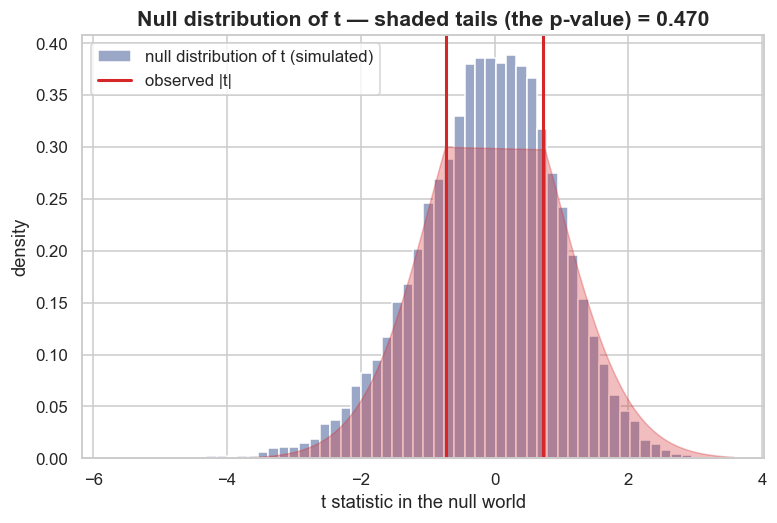

In [5]:
fig, ax = plt.subplots()
ax.hist(null_ts, bins=60, color='#9aa7c7', edgecolor='white', density=True,
        label='null distribution of t (simulated)')
for sign in (-1, 1):
    ax.axvline(sign * abs(t_obs), color='#d62728', lw=2,
               label='observed |t|' if sign == 1 else None)
xs = np.linspace(null_ts.min(), null_ts.max(), 300)
tail = xs[np.abs(xs) >= abs(t_obs)]
ax.fill_between(tail, stats.t.pdf(tail, df=n - 1), color='#d62728', alpha=0.30)
ax.set_xlabel('t statistic in the null world'); ax.set_ylabel('density')
ax.set_title(f'Null distribution of t — shaded tails (the p-value) = {p_sim:.3f}')
ax.legend(); plt.show()

In [6]:
result = stats.ttest_1samp(sample, popmean=mu0, alternative='two-sided')
print(f'simulated p-value (null world) = {p_sim:.4f}')
print(f'scipy ttest_1samp p-value      = {result.pvalue:.4f}')
print(f'scipy t statistic              = {result.statistic:.3f}   (matches ours: {t_obs:.3f})')
print('\nmatch?', np.isclose(p_sim, result.pvalue, atol=0.01))
print('The formula and the simulation agree — two views of the same idea.')

simulated p-value (null world) = 0.4704
scipy ttest_1samp p-value      = 0.4719
scipy t statistic              = 0.727   (matches ours: 0.727)

match? True
The formula and the simulation agree — two views of the same idea.


## 4) The idiom — vectorized null simulation vs. a loop

The loop in Section 3 is clear, but it asks Python to do `reps` separate draws one at a time. NumPy lets
us draw the **whole experiment at once**: ask `rng.choice` for a `(reps, n)` array — `reps` samples of
size `n` stacked as rows — then reduce **along each row** (`axis=1`) to one statistic per row. Same
answer, far less code, far faster.

In [7]:
# The loop way (how you might first think of it) — already done above as null_ts.

# The vectorized way: one (reps, n) array, then reduce each ROW to a t statistic.
samples = rng.choice(null_population, size=(reps, n), replace=True)   # reps rows, n columns
means = samples.mean(axis=1)                                          # one mean per row
sds   = samples.std(axis=1, ddof=1)                                  # one sd  per row (ddof=1!)
null_ts_vec = (means - mu0) / (sds / np.sqrt(n))                      # reps t's, no loop

p_sim_vec = np.mean(np.abs(null_ts_vec) >= np.abs(t_obs))
print(f'loop p-value       : {p_sim:.4f}')
print(f'vectorized p-value : {p_sim_vec:.4f}   <- same idea, one block, no Python loop')

import time
t0 = time.perf_counter()
for i in range(reps):
    s_null = rng.choice(null_population, size=n, replace=True)
    _ = (s_null.mean() - mu0) / (s_null.std(ddof=1) / np.sqrt(n))
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
samp = rng.choice(null_population, size=(reps, n), replace=True)
_ = (samp.mean(axis=1) - mu0) / (samp.std(axis=1, ddof=1) / np.sqrt(n))
t_vec = time.perf_counter() - t0

print(f'\n{reps:,} simulated samples:')
print(f'  Python loop : {t_loop*1000:7.1f} ms')
print(f'  vectorized  : {t_vec*1000:7.1f} ms')
print(f'  vectorized is roughly {t_loop/max(t_vec,1e-9):.0f}x faster — and it is a few short lines.')

loop p-value       : 0.4704
vectorized p-value : 0.4713   <- same idea, one block, no Python loop



20,000 simulated samples:
  Python loop :   359.4 ms
  vectorized  :     7.5 ms
  vectorized is roughly 48x faster — and it is a few short lines.


## 5) Refactor into a reusable function

We computed a p-value as "simulate a null distribution of the statistic, then take the mean of an
*at-least-as-extreme* mask." That pattern is reusable, so the programmer's reflex is to **wrap it in a
function**. We pass in the observed statistic and a *recipe* for one null draw (a little function), and
get a p-value back — for *any* test, not just this one.

In [8]:
def sim_p_value(observed_stat, simulate_null_stat, reps=20_000):
    '''Two-sided p-value by simulation.

    observed_stat      : the statistic computed from the real sample.
    simulate_null_stat : a function taking no args that returns ONE statistic
                         drawn from the null world.
    Returns the fraction of null-world statistics with |stat| >= |observed_stat|.
    '''
    null_stats = np.array([simulate_null_stat() for _ in range(reps)])
    return np.mean(np.abs(null_stats) >= np.abs(observed_stat))


def one_t_under_null():
    '''Draw one sample from the null world and return its t statistic.'''
    s = rng.choice(null_population, size=n, replace=True)
    return (s.mean() - mu0) / (s.std(ddof=1) / np.sqrt(n))


p_refactored = sim_p_value(t_obs, one_t_under_null, reps=20_000)
print(f'sim_p_value(...) p-value  = {p_refactored:.4f}')
print(f'scipy ttest_1samp p-value = {result.pvalue:.4f}')
print('match?', np.isclose(p_refactored, result.pvalue, atol=0.01))

sim_p_value(...) p-value  = 0.4695
scipy ttest_1samp p-value = 0.4719
match? True


A function is a contract: *give me an observed statistic and a way to simulate the null, I'll give you a
p-value.* Once it's correct you stop thinking about the mechanics and start thinking in **statistics and
null worlds** — which is exactly what the next section needs. To *measure* an error rate we just run a
whole test (sample → statistic → decision) thousands of times and count. Here's that loop, vectorized,
returning the fraction of tests that **reject** $H_0$.

In [9]:
def reject_rate(test_population, h0, n=50, alpha=0.05, reps=4000, seed=1):
    '''Fraction of one-sample t-tests of H0: mu = h0 that REJECT, over many fresh samples.

    We sample WITH replacement, treating the file as an effectively infinite super-population,
    so n is not capped at 2,930 and there is no finite-population correction to distort the SE.
    (Sampling WITHOUT replacement here would shrink the SE and reverse the big-n demo in Sec. 6.)
    '''
    r = np.random.default_rng(seed)
    s = r.choice(test_population, size=(reps, n), replace=True)   # reps tests at once
    t = (s.mean(axis=1) - h0) / (s.std(axis=1, ddof=1) / np.sqrt(n))
    p = 2 * stats.t.sf(np.abs(t), df=n - 1)                       # two-sided p for every row
    return np.mean(p <= alpha)

# Sanity check: testing the TRUE mean should reject ~alpha of the time (see Section 6).
print('reject_rate at the true mean:', round(reject_rate(population, h0=MU, n=50), 3))

reject_rate at the true mean: 0.057


## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — **predict the
number before you run it.**

1. **Type I error is $\alpha$.** When $H_0$ is *true*, a test should falsely reject only $\alpha$ of the
   time. Make $H_0$ true by testing the real mean, and measure it:
   `type1 = reject_rate(population, h0=MU, n=50, alpha=0.05, reps=8000)`. Print it. Is it near **0.05**?
   Then change `alpha=0.01` and confirm the rate drops toward **0.01** — *you set your own false-alarm
   rate.*

2. **Power rises with effect size.** When $H_0$ is *false*, the chance of correctly rejecting is **power**.
   Make $H_0$ false by testing a *wrong* value `MU - e`, so the truth is `e` sq ft away:
   ```python
   for e in [0, 25, 50, 75, 100, 150, 200, 250]:
       print(f'effect {e:3d} sq ft -> power {reject_rate(population, h0=MU - e, n=50, seed=2):.3f}')
   ```
   At `e = 0` you're back to the Type I rate (~0.05); watch power climb toward 1 as the lie gets bigger.

3. **Power rises with sample size.** Hold the effect fixed at a stubborn 75 sq ft and grow `n`:
   ```python
   for nn in [15, 30, 50, 100, 200, 400]:
       print(f'n {nn:3d} -> power {reject_rate(population, h0=MU - 75, n=nn, seed=3):.3f}')
   ```
   More data shrinks the standard error, so even a modest effect becomes detectable. Plot it with
   `plt.plot(sizes, powers, 's-')` if you like.

4. **Big $n$ manufactures "significance."** A *trivial* 5 sq ft effect should be ignorable — but with
   enough data the test rejects it anyway. Compare two sample sizes:
   `reject_rate(population, h0=MU - 5, n=20_000, reps=2000)` versus
   `reject_rate(population, h0=MU - 5, n=40, reps=2000)`. The huge-$n$ rate climbs well above 0.05 while
   the small-$n$ rate sits near the floor. **Significant $\ne$ large** — this works *because* we sample
   *with replacement* from the super-population (sampling without replacement would cap $n$ at 2,930 and
   reverse the demo).

## What you learned

**Coding**
- A **seeded generator** (`rng = np.random.default_rng(0)`) makes "chance" reproducible — same seed, same
  numbers, every run.
- A **p-value is the mean of a boolean mask**: `np.mean(np.abs(null_stats) >= np.abs(observed))` counts the
  fraction of the null world at least as extreme as your data.
- The **vectorized idiom** — draw a `(reps, n)` array and reduce along `axis=1` — replaces a Python loop,
  reads cleaner, and runs far faster; always pass **`ddof=1`** for a sample SD.
- **Refactor repeated work into a function**: `sim_p_value(observed, simulate_null_fn)` and `reject_rate(...)`
  turn "simulate, then count" into one reusable call.

**Statistics (now demystified)**
- The **p-value** you built by simulation matched `scipy.stats.ttest_1samp` to about a hundredth — they are
  two views of the same tail area.
- **Type I error rate is $\alpha$**: testing a *true* null rejects ~5% of the time at `alpha=0.05` — a
  number you *choose*, not avoid.
- **Power** (rejecting a *false* null) rises with both **effect size** and **sample size $n$**; with a huge
  $n$ even a trivial effect becomes "significant," so significant is never the same as large.

**Back to the core lesson** ([Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb))
for the *meaning* of these numbers, or read on through the course.

---

**↩ Back to the lesson:** [Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](13-hypothesis-testing~another-dataset.ipynb)